In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('loan_database.db')
df = pd.read_csv('Loan_app/loan_data.csv')

df.to_sql('loans', conn, if_exists='replace', index=False)
print('Database created! You are ready to write SQL.')

Database created! You are ready to write SQL.


In [2]:
query = 'SELECT * FROM loans LIMIT 5'
result = pd.read_sql(query, conn)
result

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [3]:
query = 'SELECT person_age, person_income FROM loans WHERE person_age > 23'
pd.read_sql(query, conn)


,person_age,person_income
0,25.0,12438.0
1,24.0,66135.0
2,26.0,93471.0
3,24.0,95550.0
4,24.0,100684.0
...,...,...
34199,27.0,47971.0
34200,37.0,65800.0
34201,33.0,56942.0
34202,29.0,33164.0


In [4]:
query = '''
SELECT person_age, person_income, loan_intent
FROM loans
WHERE person_age > 23 AND loan_intent = 'MEDICAL'
'''
pd.read_sql(query,conn)

,person_age,person_income,loan_intent
0,25.0,12438.0,MEDICAL
1,24.0,66135.0,MEDICAL
2,24.0,95550.0,MEDICAL
3,26.0,361076.0,MEDICAL
4,26.0,75503.0,MEDICAL
...,...,...,...
6707,26.0,42960.0,MEDICAL
6708,28.0,68381.0,MEDICAL
6709,24.0,75941.0,MEDICAL
6710,24.0,31924.0,MEDICAL


In [5]:
query = '''
SELECT AVG(person_income) AS avg_income
FROM LOANS
'''
pd.read_sql(query, conn)

,avg_income
0,80319.053222


In [6]:
query ='''
SELECT loan_intent, COUNT(*) AS total FROM loans
GROUP BY loan_intent
'''
pd.read_sql(query, conn)

,loan_intent,total
0,DEBTCONSOLIDATION,7145
1,EDUCATION,9153
2,HOMEIMPROVEMENT,4783
3,MEDICAL,8548
4,PERSONAL,7552
5,VENTURE,7819


In [7]:
query = '''
SELECT person_age, person_income, loan_intent
FROM loans
WHERE person_age > 25  AND person_income 
> 5000
'''
pd.read_sql(query, conn)

,person_age,person_income,loan_intent
0,26.0,93471.0,EDUCATION
1,26.0,130713.0,EDUCATION
2,26.0,114645.0,HOMEIMPROVEMENT
3,26.0,361076.0,MEDICAL
4,26.0,75503.0,MEDICAL
...,...,...,...
24554,27.0,35512.0,PERSONAL
24555,27.0,47971.0,MEDICAL
24556,37.0,65800.0,HOMEIMPROVEMENT
24557,33.0,56942.0,DEBTCONSOLIDATION


In [8]:
query = '''
SELECT person_age, loan_intent
FROM loans
WHERE loan_intent = 'MEDICAL' OR 
loan_intent = 'EDUCATION'
'''
pd.read_sql(query, conn)

,person_age,loan_intent
0,21.0,EDUCATION
1,25.0,MEDICAL
2,23.0,MEDICAL
3,24.0,MEDICAL
4,26.0,EDUCATION
...,...,...
17696,24.0,MEDICAL
17697,24.0,EDUCATION
17698,24.0,MEDICAL
17699,27.0,MEDICAL


In [9]:
query = '''
SELECT *
FROM loans
WHERE person_education LIKE '%High%'
'''
pd.read_sql(query, conn)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
1,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
2,21.0,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2.0,532,No,1
3,24.0,female,High School,95550.0,5,RENT,35000.0,MEDICAL,11.11,0.37,4.0,585,No,1
4,21.0,female,High School,12739.0,0,OWN,1600.0,VENTURE,14.74,0.13,3.0,640,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11967,25.0,female,High School,91444.0,1,MORTGAGE,5696.0,DEBTCONSOLIDATION,15.49,0.06,4.0,604,No,1
11968,24.0,female,High School,75941.0,1,RENT,20000.0,MEDICAL,14.85,0.26,4.0,592,No,1
11969,24.0,male,High School,37786.0,0,MORTGAGE,13500.0,EDUCATION,13.43,0.36,4.0,612,No,1
11970,27.0,female,High School,35512.0,4,RENT,5000.0,PERSONAL,15.83,0.14,5.0,505,No,1


In [10]:
query = '''
SELECT person_age, person_income
FROM loans
ORDER BY person_income DESC
'''
pd.read_sql(query, conn)

,person_age,person_income
0,144.0,7200766.0
1,109.0,5556399.0
2,116.0,5545545.0
3,42.0,2448661.0
4,60.0,2280980.0
...,...,...
44995,53.0,8000.0
44996,39.0,8000.0
44997,36.0,8000.0
44998,23.0,8000.0


In [11]:
query = '''
SELECT *
FROM loans
ORDER BY person_income DESC
LIMIT 5
'''
pd.read_sql(query, conn)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,144.0,female,Associate,7200766.0,124,MORTGAGE,5000.0,PERSONAL,12.73,0.0,25.0,850,No,0
1,109.0,male,High School,5556399.0,85,MORTGAGE,6195.0,VENTURE,12.58,0.0,22.0,792,No,0
2,116.0,male,Bachelor,5545545.0,93,MORTGAGE,3823.0,VENTURE,12.15,0.0,24.0,708,No,0
3,42.0,male,High School,2448661.0,16,RENT,8450.0,VENTURE,12.29,0.0,15.0,635,Yes,0
4,60.0,female,High School,2280980.0,37,MORTGAGE,1500.0,PERSONAL,11.01,0.0,21.0,682,Yes,0


In [12]:
query = '''
SELECT loan_intent, count(*) AS total FROM loans
GROUP BY loan_intent
HAVING total > 100
'''
pd.read_sql(query, conn)

,loan_intent,total
0,DEBTCONSOLIDATION,7145
1,EDUCATION,9153
2,HOMEIMPROVEMENT,4783
3,MEDICAL,8548
4,PERSONAL,7552
5,VENTURE,7819


In [13]:
query = '''
SELECT person_income, AVG(person_income) AS average_income
FROM loans
GROUP BY person_education
ORDER BY average_income DESC
'''
pd.read_sql(query, conn)


,person_income,average_income
0,56325.0,87234.541063
1,100684.0,80641.623628
2,71948.0,80491.924355
3,12282.0,80224.597645
4,79753.0,79703.319725


In [14]:
pd.read_sql('PRAGMA table_info(loans);', conn)

,cid,name,type,notnull,dflt_value,pk
0,0,person_age,REAL,0,None,0
1,1,person_gender,TEXT,0,None,0
2,2,person_education,TEXT,0,None,0
3,3,person_income,REAL,0,None,0
4,4,person_emp_exp,INTEGER,0,None,0
5,5,person_home_ownership,TEXT,0,None,0
6,6,loan_amnt,REAL,0,None,0
7,7,loan_intent,TEXT,0,None,0
8,8,loan_int_rate,REAL,0,None,0
9,9,loan_percent_income,REAL,0,None,0


In [15]:
query = 'SELECT * FROM loans' 
pd.read_sql(query, conn)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [16]:
query = '''
SELECT person_education, loan_intent, (loan_amnt / person_income) AS debt_ratio
FROM loans
WHERE person_income > 0
LIMIT 10
'''
pd.read_sql(query, conn)

,person_education,loan_intent,debt_ratio
0,Master,PERSONAL,0.486462
1,High School,EDUCATION,0.081420
2,High School,MEDICAL,0.442193
3,Bachelor,MEDICAL,0.438855
4,Master,MEDICAL,0.529221
5,High School,VENTURE,0.193035
6,Bachelor,EDUCATION,0.374448
7,High School,MEDICAL,0.366300
8,Associate,PERSONAL,0.347622
9,High School,VENTURE,0.125599


In [17]:
query = '''
SELECT person_education, loan_intent, loan_amnt, person_income
FROM loans
WHERE loan_intent IN ('MEDICAL', 'DEBTCONSOLIDATION')
ORDER BY loan_amnt DESC
LIMIT 5
'''
pd.read_sql(query, conn)

,person_education,loan_intent,loan_amnt,person_income
0,Bachelor,MEDICAL,35000.0,79753.0
1,Master,MEDICAL,35000.0,66135.0
2,High School,MEDICAL,35000.0,95550.0
3,High School,MEDICAL,35000.0,111369.0
4,Bachelor,DEBTCONSOLIDATION,35000.0,136628.0


In [18]:
query = '''
SELECT
    person_home_ownership,   
    AVG(credit_score) AS avg_credit_score,
     COUNT(*) AS total_applicants
FROM loans
GROUP BY person_home_ownership
ORDER BY avg_credit_score DESC
'''
pd.read_sql(query, conn)

,person_home_ownership,avg_credit_score,total_applicants
0,MORTGAGE,633.036779,18489
1,RENT,632.364458,23443
2,OWN,632.058285,2951
3,OTHER,627.803419,117


In [19]:
df = pd.read_sql('SELECT * FROM loans', conn)
df[['person_income', 'loan_amnt','loan_intent']].head()

,person_income,loan_amnt,loan_intent
0,71948.0,35000.0,PERSONAL
1,12282.0,1000.0,EDUCATION
2,12438.0,5500.0,MEDICAL
3,79753.0,35000.0,MEDICAL
4,66135.0,35000.0,MEDICAL


In [20]:
query = '''
SELECT 
       person_gender,
       loan_amnt, 
       CASE
          WHEN loan_amnt > 5000
THEN 'High'
          WHEN loan_amnt BETWEEN
2000 AND 5000 THEN 'medium'
          ELSE 'Low'
        END AS loan_category
FROM loans
LIMIT 10
'''
pd.read_sql(query, conn)



,person_gender,loan_amnt,loan_category
0,female,35000.0,High
1,female,1000.0,Low
2,female,5500.0,High
3,female,35000.0,High
4,male,35000.0,High
5,female,2500.0,medium
6,female,35000.0,High
7,female,35000.0,High
8,female,35000.0,High
9,female,1600.0,Low


In [21]:
query = '''
SELECT person_age, loan_amnt
FROM loans
WHERE loan_amnt IN (
     SELECT loan_amnt 
     FROM loans
     ORDER BY loan_amnt DESC
     LIMIT 5
)
'''
pd.read_sql(query, conn)

,person_age,loan_amnt
0,22.0,35000.0
1,23.0,35000.0
2,24.0,35000.0
3,26.0,35000.0
4,24.0,35000.0
...,...,...
229,27.0,35000.0
230,27.0,35000.0
231,23.0,35000.0
232,34.0,35000.0


In [22]:
query = '''
SELECT person_age, person_income, loan_intent
FROM loans
WHERE loan_intent NOT IN (
     SELECT DISTINCT loan_intent
     FROM loans
     WHERE loan_intent = 'MEDICAL' OR loan_intent = 'VENTURE'
)
'''
pd.read_sql(query, conn)

,person_age,person_income,loan_intent
0,22.0,71948.0,PERSONAL
1,21.0,12282.0,EDUCATION
2,26.0,93471.0,EDUCATION
3,24.0,100684.0,PERSONAL
4,21.0,13113.0,HOMEIMPROVEMENT
...,...,...,...
28628,27.0,35512.0,PERSONAL
28629,37.0,65800.0,HOMEIMPROVEMENT
28630,33.0,56942.0,DEBTCONSOLIDATION
28631,29.0,33164.0,EDUCATION


In [23]:
query = '''
SELECT person_age, person_income, loan_intent
FROM loans
WHERE person_income > (
     SELECT AVG(person_income)
     FROM LOANS
)
LIMIT 10
'''
pd.read_sql(query, conn)

,person_age,person_income,loan_intent
0,26.0,93471.0,EDUCATION
1,24.0,95550.0,MEDICAL
2,24.0,100684.0,PERSONAL
3,22.0,102985.0,VENTURE
4,23.0,114860.0,VENTURE
5,26.0,130713.0,EDUCATION
6,23.0,138998.0,EDUCATION
7,23.0,600891.0,DEBTCONSOLIDATION
8,23.0,144943.0,EDUCATION
9,23.0,111369.0,MEDICAL


In [24]:
query = '''
SELECT DISTINCT person_age, person_income
FROM loans
WHERE credit_score IN (
     SELECT credit_score
     FROM loans
     WHERE credit_score > 700
)
'''
pd.read_sql(query, conn)

,person_age,person_income
0,26.0,93471.0
1,26.0,130713.0
2,23.0,136628.0
3,144.0,300616.0
4,24.0,88950.0
...,...,...
2688,27.0,53273.0
2689,43.0,184295.0
2690,36.0,61015.0
2691,34.0,41876.0


In [25]:
query = '''
SELECT person_age, person_income, loan_amnt
FROM loans
WHERE
previous_loan_defaults_on_file NOT 
IN (
     SELECT DISTINCT
previous_loan_defaults_on_file
     FROM loans
     WHERE
previous_loan_defaults_on_file = 'Y'
)
'''
pd.read_sql(query, conn)
     

,person_age,person_income,loan_amnt
0,22.0,71948.0,35000.0
1,21.0,12282.0,1000.0
2,25.0,12438.0,5500.0
3,23.0,79753.0,35000.0
4,24.0,66135.0,35000.0
...,...,...,...
44995,27.0,47971.0,15000.0
44996,37.0,65800.0,9000.0
44997,33.0,56942.0,2771.0
44998,29.0,33164.0,12000.0


In [26]:
query = '''
SELECT
    person_age,
    loan_intent,
    loan_amnt
FROM loans
WHERE loan_amnt > (
     SELECT AVG(loan_amnt)
     FROM loans
)
ORDER BY loan_amnt ASC
LIMIT 10
'''
pd.read_sql(query, conn)

    

,person_age,loan_intent,loan_amnt
0,35.0,VENTURE,9586.0
1,24.0,PERSONAL,9587.0
2,36.0,MEDICAL,9588.0
3,37.0,MEDICAL,9589.0
4,27.0,VENTURE,9590.0
5,23.0,DEBTCONSOLIDATION,9591.0
6,23.0,EDUCATION,9591.0
7,24.0,EDUCATION,9600.0
8,23.0,EDUCATION,9600.0
9,21.0,MEDICAL,9600.0


In [27]:
query = '''
SELECT person_age, loan_intent, loan_amnt,
    RANK() OVER (PARTITION BY 
loan_intent ORDER BY loan_amnt 
DESC) as loan_rank
FROM loans
LIMIT 20
'''
pd.read_sql(query, conn)

,person_age,loan_intent,loan_amnt,loan_rank
0,23.0,DEBTCONSOLIDATION,35000.0,1
1,24.0,DEBTCONSOLIDATION,35000.0,1
2,24.0,DEBTCONSOLIDATION,35000.0,1
3,25.0,DEBTCONSOLIDATION,35000.0,1
4,23.0,DEBTCONSOLIDATION,35000.0,1
5,24.0,DEBTCONSOLIDATION,35000.0,1
6,26.0,DEBTCONSOLIDATION,35000.0,1
7,25.0,DEBTCONSOLIDATION,35000.0,1
8,24.0,DEBTCONSOLIDATION,35000.0,1
9,25.0,DEBTCONSOLIDATION,35000.0,1


In [28]:
query = '''
SELECT *
FROM loans
WHERE person_age > 100
   OR person_emp_exp > 60
   OR person_income > 2000000
'''
pd.read_sql(query, conn)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,144.0,male,Bachelor,300616.0,125,RENT,4800.0,VENTURE,13.57,0.02,3.0,789,No,0
1,144.0,male,Associate,241424.0,121,MORTGAGE,6000.0,EDUCATION,11.86,0.02,2.0,807,No,0
2,123.0,female,High School,97140.0,101,RENT,20400.0,EDUCATION,10.25,0.21,3.0,805,Yes,0
3,123.0,male,Bachelor,94723.0,100,RENT,20000.0,VENTURE,11.01,0.21,4.0,714,Yes,0
4,42.0,male,High School,2448661.0,16,RENT,8450.0,VENTURE,12.29,0.00,15.0,635,Yes,0
5,144.0,female,Associate,7200766.0,124,MORTGAGE,5000.0,PERSONAL,12.73,0.00,25.0,850,No,0
6,94.0,male,High School,29738.0,76,RENT,6500.0,MEDICAL,11.01,0.22,27.0,773,No,0
7,80.0,male,High School,77894.0,62,RENT,6800.0,MEDICAL,11.71,0.09,25.0,673,No,0
8,63.0,male,High School,2139143.0,43,RENT,12025.0,EDUCATION,14.27,0.01,30.0,724,No,0
9,84.0,male,High School,114705.0,61,MORTGAGE,10000.0,PERSONAL,7.51,0.09,24.0,784,Yes,0


In [29]:
pd.read_sql('SELECT * FROM loans LIMIT 0', conn).columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

In [30]:
query = '''
SELECT 
    person_age,
    loan_int_rate AS
original_rate,
    COALESCE(loan_int_rate, 11.0)
AS cleaned_rate
FROM loans
WHERE loan_int_rate IS NULL
LIMIT 10
'''
pd.read_sql(query, conn)

,person_age,original_rate,cleaned_rate


In [31]:
query = '''
SELECT
    COUNT(*) as total_rows,
    SUM(CASE WHEN person_age
> 100 THEN 1 ELSE 0 END) as impossible_ages
FROM loans
'''
pd.read_sql(query, conn)

,total_rows,impossible_ages
0,45000,7


In [32]:
query = '''
SELECT * 
FROM loans
WHERE person_age <= 100
'''
df_clean = pd.read_sql(query, conn)

In [33]:
print(list(pd.read_sql('SELECT * FROM loans LIMIT 1', conn).columns))

['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status']


In [34]:
query = '''
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN loan_int_rate
IS NULL THEN 1 ELSE 0 END) AS missing_rates
FROM loans
WHERE person_age <= 100
'''
pd.read_sql(query, conn)
    

,total_rows,missing_rates
0,44993,0


In [35]:
query = '''
SELECT person_education, COUNT(*)
as count
FROM loans
WHERE person_age <= 100
GROUP BY person_education
'''
pd.read_sql(query, conn)

,person_education,count
0,Associate,12026
1,Bachelor,13396
2,Doctorate,621
3,High School,11970
4,Master,6980


In [36]:
query = '''
SELECT
    UPPER(TRIM(person_education))
as cleaned_education,
    COUNT(*) as total
FROM loans
WHERE person_age <= 100
GROUP BY cleaned_education
'''
pd.read_sql(query, conn)

,cleaned_education,total
0,ASSOCIATE,12026
1,BACHELOR,13396
2,DOCTORATE,621
3,HIGH SCHOOL,11970
4,MASTER,6980


In [37]:
query = '''
WITH cleaned_loans AS (
SELECT * FROM loans
WHERE person_age <= 100
)
SELECT
    person_education,
    AVG(loan_amnt) as avg_loan,
    COUNT(*) as customer_count
FROM cleaned_loans
GROUP BY person_education
ORDER BY avg_loan DESC
'''
pd.read_sql(query, conn)

,person_education,avg_loan,customer_count
0,Doctorate,9930.932367,621
1,Associate,9628.675453,12026
2,Master,9595.030229,6980
3,Bachelor,9556.116453,13396
4,High School,9542.795739,11970


In [38]:
query = '''
WITH clean_data AS (
    SELECT * FROM loans
    WHERE person_age <= 100
)
SELECT
     person_education,
     AVG(loan_amnt) AS avg_loan,
     AVG(loan_int_rate) AS
avg_interest_rate,
     COUNT(*) AS total_borrowers
FROM clean_data
GROUP BY person_education
ORDER BY avg_interest_rate DESC
'''
pd.read_sql(query, conn)


,person_education,avg_loan,avg_interest_rate,total_borrowers
0,Doctorate,9930.932367,11.066860,621
1,Bachelor,9556.116453,11.034703,13396
2,Master,9595.030229,11.002748,6980
3,High School,9542.795739,10.998723,11970
4,Associate,9628.675453,10.981691,12026


In [39]:
query = '''
WITH clean_data AS (
    SELECT * FROM loans
    WHERE person_age <= 100
)
SELECT
    CASE
       WHEN person_age < 30 THEN
'1. young Professional'
        WHEN person_age BETWEEN 30
AND 50 THEN '2. Mid-Career'
        ELSE '3. Senior'
    END AS life_stage,
    AVG(loan_amnt) as avg_loan,
    COUNT(*) as total_count
FROM clean_data
GROUP BY life_stage
ORDER BY life_stage ASC
'''
pd.read_sql(query, conn)

,life_stage,avg_loan,total_count
0,1. young Professional,9448.977763,32378
1,2. Mid-Career,9922.536766,12294
2,3. Senior,10122.127726,321


In [40]:
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';",
conn)


,name
0,loans


In [41]:
query = '''
WITH final_clean AS (
    SELECT * FROM loans WHERE person_age <= 100
)
SELECT
    CASE
       WHEN person_age < 30 THEN 
'young'
       WHEN person_age BETWEEN 30 AND 50 THEN 'Mid'
       ELSE 'Senior'
    END AS life_stage,
    person_home_ownership,
    AVG(loan_amnt) as avg_loan,
    AVG(loan_int_rate) as  avg_rate,
    COUNT(*) as count
FROM final_clean
GROUP BY life_stage,
person_home_ownership
ORDER BY life_stage, count DESC
'''
pd.read_sql(query, conn)

,life_stage,person_home_ownership,avg_loan,avg_rate,count
0,Mid,RENT,8975.314338,11.412056,6054
1,Mid,MORTGAGE,11105.499631,10.680810,5422
2,Mid,OWN,8970.624843,10.784567,797
3,Mid,OTHER,13690.809524,12.649524,21
4,Senior,RENT,9961.833333,11.424010,192
5,Senior,MORTGAGE,10857.092593,10.410926,108
6,Senior,OWN,7807.857143,10.624762,21
7,young,RENT,8664.836396,11.365548,17194
8,young,MORTGAGE,10554.682208,10.506919,12955
9,young,OWN,8995.486170,10.845166,2133


In [42]:
df_final = pd.read_sql(query, conn)

Text(0.5, 1.0, 'Average Loan Amount by Life Stage and Home Ownership')

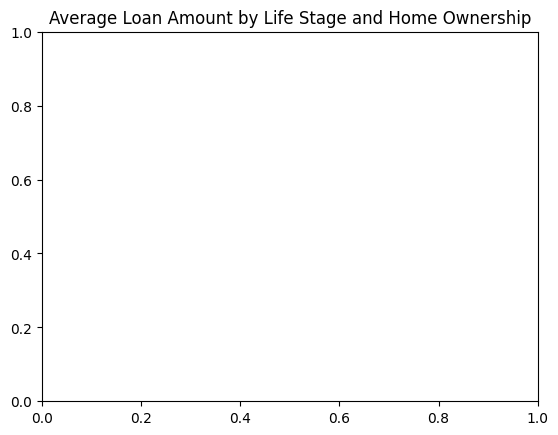

In [49]:
import matplotlib.pyplot as plt
plt.title('Average Loan Amount by Life Stage and Home Ownership')

In [53]:
!pip install seaborn

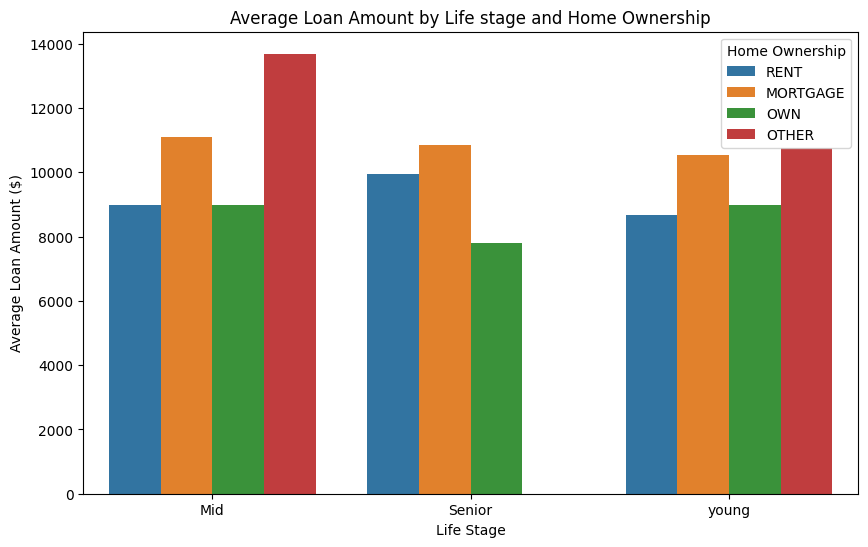

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=df_final,
x='life_stage',y='avg_loan',            
hue='person_home_ownership')

plt.title('Average Loan Amount by Life stage and Home Ownership')
plt.xlabel('Life Stage')
plt.ylabel('Average Loan Amount ($)')
plt.legend(title='Home Ownership')
plt.show()